<a href="https://colab.research.google.com/github/roshanmohammed038-collab/ML_Training_models/blob/main/unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score,classification_report
import seaborn as sns
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [44]:
X,y=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [13]:
df=pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [14]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [18]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [19]:
inertia=[]
k_range=range(1,11)

In [21]:
for k in k_range:
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)

In [22]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

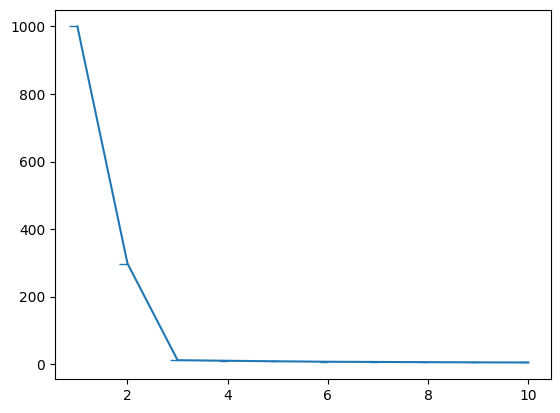

In [27]:
plt.plot(k_range,inertia,marker=0)

In [36]:
kmeans_final=KMeans(n_clusters=3,random_state=42)


In [37]:
cluster_labels=kmeans_final.fit_predict(x_scaled)

In [38]:
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [39]:
df['cluster']=cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

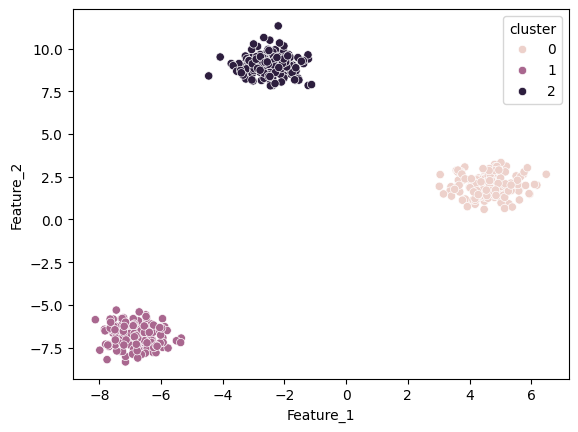

In [43]:
sns.scatterplot(data=df,x='Feature_1',y='Feature_2',hue='cluster')

In [41]:
from sklearn.datasets import make_moons

In [45]:
X,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [48]:
from sklearn.cluster import KMeans,DBSCAN

In [49]:
df=pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [50]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [52]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans_labels=kmeans.fit_predict(x_scaled)

In [53]:
df['kmeans_cluster']=kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

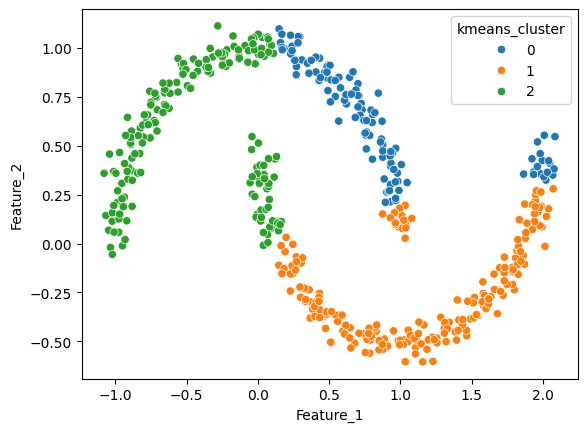

In [54]:
sns.scatterplot(data=df,x='Feature_1',y='Feature_2',hue='kmeans_cluster',palette='tab10')

In [55]:
dbscan=DBSCAN(eps=0.2,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled )

In [56]:
df['db_clusters']=dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

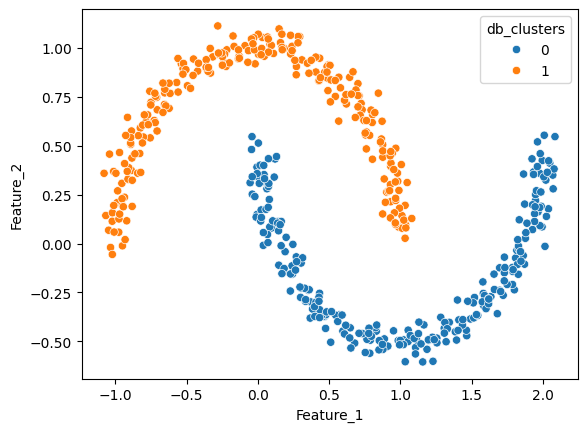

In [57]:
sns.scatterplot(data=df,x='Feature_1',y='Feature_2',hue='db_clusters',palette='tab10')